# 06 - Statistical Analysis

## Objective

This notebook performs statistical analysis on the feature-engineered AirIntel dataset.

The objectives are:

- Understand statistical properties of the data
- Validate assumptions using statistical tests
- Measure relationships between variables
- Detect multicollinearity
- Perform hypothesis testing
- Rank statistically important features
- Reduce dimensionality using PCA

The insights generated here will guide feature selection and machine learning in subsequent notebooks.

In [2]:
# Import Required Libraries

# Suppress warnings
import warnings
warnings.filterwarnings("ignore")

# File handling
from pathlib import Path

# Numerical computing
import numpy as np

# Data manipulation
import pandas as pd

# Statistical analysis
from scipy import stats

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# QQ Plot
import statsmodels.api as sm

# VIF
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Feature Selection
from sklearn.feature_selection import (
    mutual_info_regression,
    SelectKBest,
    f_regression
)

# Scaling
from sklearn.preprocessing import StandardScaler

# PCA
from sklearn.decomposition import PCA

In [3]:
# Project Paths

PROJECT_DIR = Path("../")

DATA_DIR = PROJECT_DIR / "data"

REPORT_DIR = PROJECT_DIR / "reports"

TABLE_DIR = REPORT_DIR / "tables"

TABLE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

In [4]:
# Visualization Theme

sns.set_theme(
    style="whitegrid",
    palette="pastel",
    font_scale=1.0
)

PALETTE = sns.color_palette("pastel")

FIG_SIZE = (10,6)

LARGE_FIG = (14,6)

HEATMAP_SIZE = (12,8)

plt.rcParams["figure.dpi"] = 120

In [5]:
# Reproducibility

RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)

In [6]:
# Load Dataset

DATA_PATH = DATA_DIR / "processed" / "feature_engineered_airintel.parquet"

df = pd.read_parquet(DATA_PATH)

print(f"Dataset Shape : {df.shape}")

Dataset Shape : (842160, 248)


In [7]:
# Preview Dataset
df.head()

,City,State,Latitude,Longitude,Datetime,Year,Month,Day,Hour,Day_of_Week,...,SO2_ugm3_Change,SO2_ugm3_PctChange,O3_ugm3_Change,O3_ugm3_PctChange,PM2_5_ugm3_Volatility_24H,PM10_ugm3_Volatility_24H,CO_ugm3_Volatility_24H,NO2_ugm3_Volatility_24H,SO2_ugm3_Volatility_24H,O3_ugm3_Volatility_24H
0,Agartala,Tripura,23.8315,91.2868,2022-08-05 00:00:00,2022,8,5,0,4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Agartala,Tripura,23.8315,91.2868,2022-08-05 01:00:00,2022,8,5,1,4,...,0.3,0.111111,1.0,0.031250,0.450000,0.650000,0.500000,1.650000,0.150000,0.500000
2,Agartala,Tripura,23.8315,91.2868,2022-08-05 02:00:00,2022,8,5,2,4,...,0.3,0.100000,1.0,0.030303,0.616441,0.828654,0.471405,2.735365,0.244949,0.816497
3,Agartala,Tripura,23.8315,91.2868,2022-08-05 03:00:00,2022,8,5,3,4,...,0.0,0.000000,-2.0,-0.058824,1.017349,1.408900,0.500000,3.030986,0.248747,0.829156
4,Agartala,Tripura,23.8315,91.2868,2022-08-05 04:00:00,2022,8,5,4,4,...,-0.1,-0.030303,-2.0,-0.062500,1.238386,1.712776,1.095445,3.046572,0.228035,1.326650


In [8]:
# Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 842160 entries, 0 to 842159
Columns: 248 entries, City to O3_ugm3_Volatility_24H
dtypes: category(2), datetime64[ns](1), float64(196), int32(4), int64(34), object(11)
memory usage: 1.5+ GB


In [9]:
# Dataset Overview
dataset_summary = pd.DataFrame({

    "Metric":[

        "Rows",

        "Columns",

        "Numerical Features",

        "Categorical Features",

        "Memory Usage (MB)"

    ],

    "Value":[

        len(df),

        df.shape[1],

        len(df.select_dtypes(include=np.number).columns),

        len(df.select_dtypes(exclude=np.number).columns),

        round(

            df.memory_usage(deep=True).sum() /

            1024**2,

            2

        )

    ]

})

dataset_summary

,Metric,Value
0,Rows,842160.00
1,Columns,248.00
2,Numerical Features,234.00
3,Categorical Features,14.00
4,Memory Usage (MB),1986.17


## Descriptive Statistics

In [10]:
# Select Pollutant Columns

pollutant_cols = [

    "PM2_5_ugm3",

    "PM10_ugm3",

    "CO_ugm3",

    "NO2_ugm3",

    "SO2_ugm3",

    "O3_ugm3"

]

In [11]:
# Descriptive Statistics

descriptive_stats = pd.DataFrame({

    "Mean":df[pollutant_cols].mean(),

    "Median":df[pollutant_cols].median(),

    "Mode":df[pollutant_cols].mode().iloc[0],

    "Std":df[pollutant_cols].std(),

    "Variance":df[pollutant_cols].var(),

    "Minimum":df[pollutant_cols].min(),

    "Q1":df[pollutant_cols].quantile(0.25),

    "Q3":df[pollutant_cols].quantile(0.75),

    "Maximum":df[pollutant_cols].max(),

    "IQR":(

        df[pollutant_cols].quantile(0.75)

        -

        df[pollutant_cols].quantile(0.25)

    ),

    "Skewness":df[pollutant_cols].skew(),

    "Kurtosis":df[pollutant_cols].kurt()

})

descriptive_stats.round(3)

,Mean,Median,Mode,Std,Variance,Minimum,Q1,Q3,Maximum,IQR,Skewness,Kurtosis
PM2_5_ugm3,34.740,25.9,13.4,30.843,951.321,0.1,14.7,44.2,581.1,29.5,2.543,10.508
PM10_ugm3,56.257,39.0,19.2,83.837,7028.648,0.1,21.5,66.4,3263.4,44.9,13.342,303.177
CO_ugm3,450.891,333.0,246.0,434.552,188835.570,56.0,235.0,508.0,14504.0,273.0,5.937,70.016
NO2_ugm3,16.133,9.0,0.9,20.813,433.198,0.0,3.7,19.9,336.0,16.2,3.112,14.039
SO2_ugm3,13.599,6.9,0.6,20.617,425.061,0.0,2.8,15.8,424.6,13.0,4.475,31.324
O3_ugm3,80.480,73.0,52.0,46.196,2134.036,0.0,47.0,108.0,930.0,61.0,1.137,4.124


In [12]:
# Save Descriptive Statistics

descriptive_stats.to_csv(

    TABLE_DIR /

    "descriptive_statistics.csv"

)

## Distribution Analysis

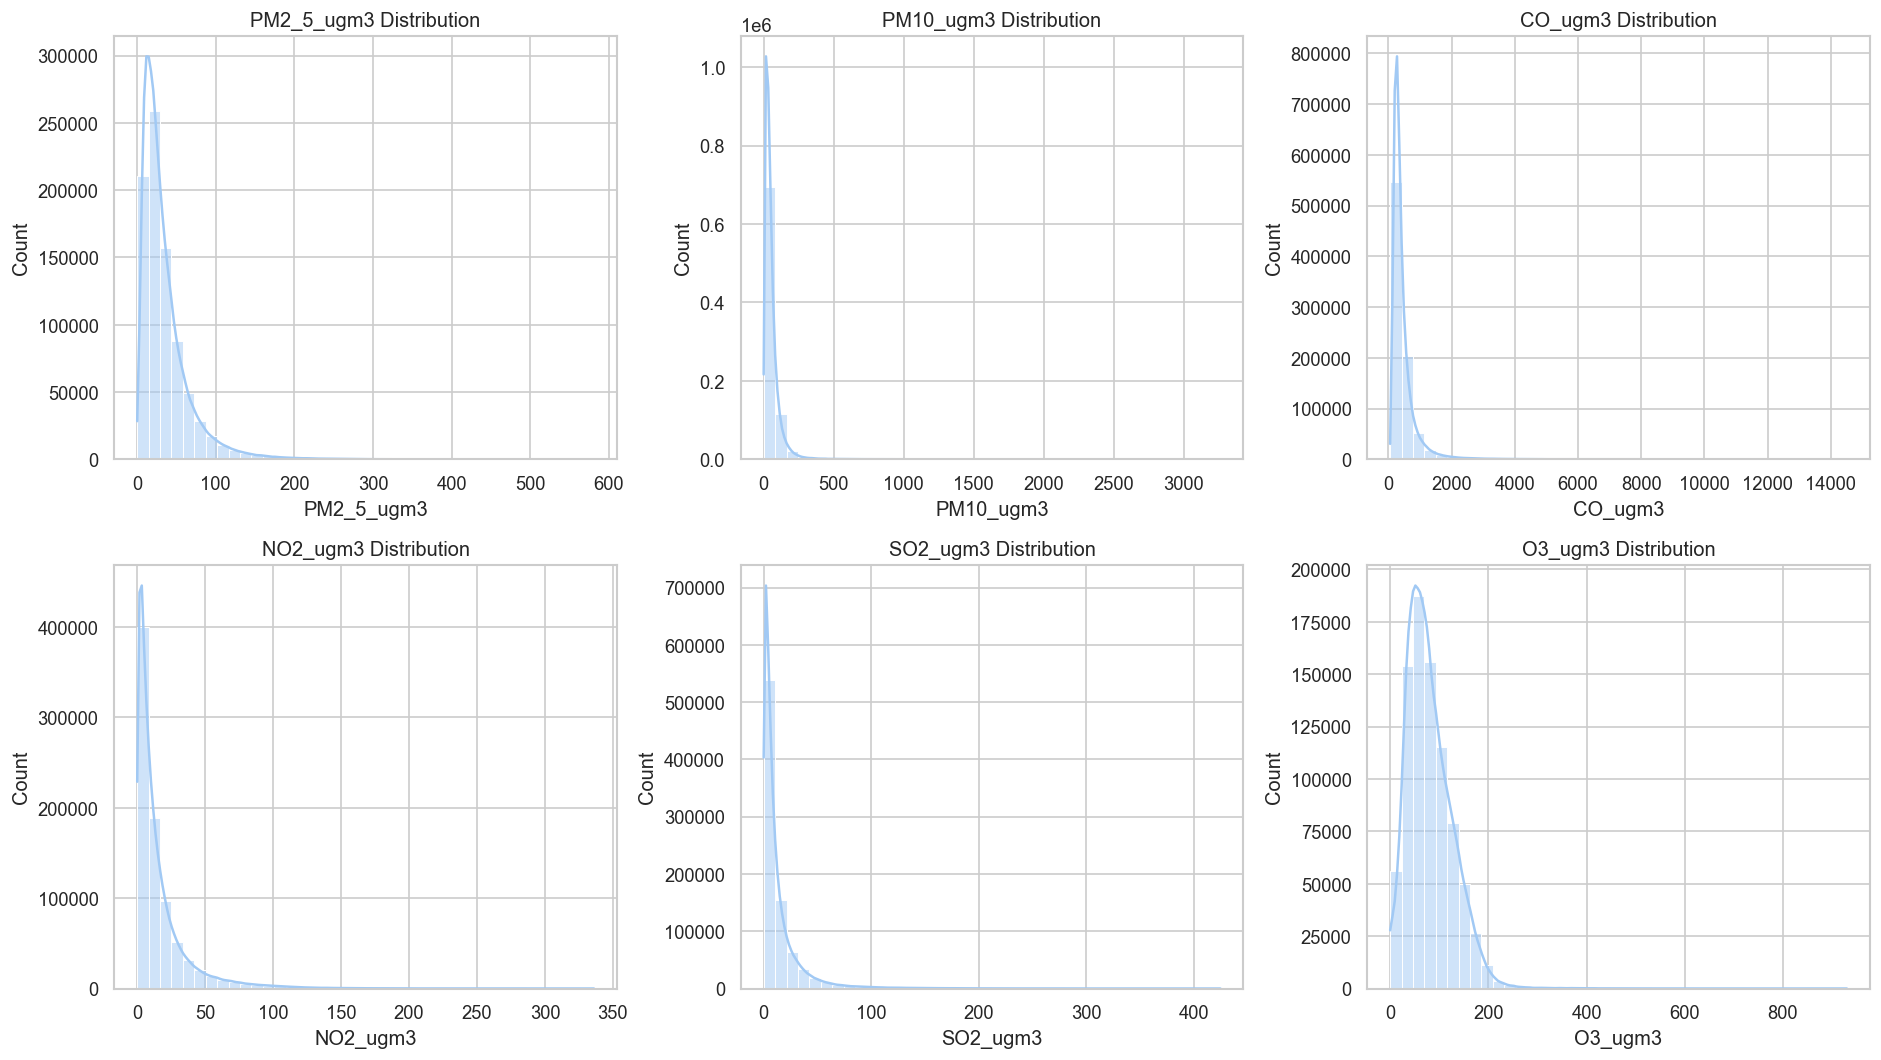

In [13]:
# Distribution of major pollutants

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for ax, col in zip(axes.flatten(), pollutant_cols):

    sns.histplot(
        df[col],
        kde=True,
        bins=40,
        color=PALETTE[0],
        ax=ax
    )

    ax.set_title(f"{col} Distribution")

plt.tight_layout()

plt.show()

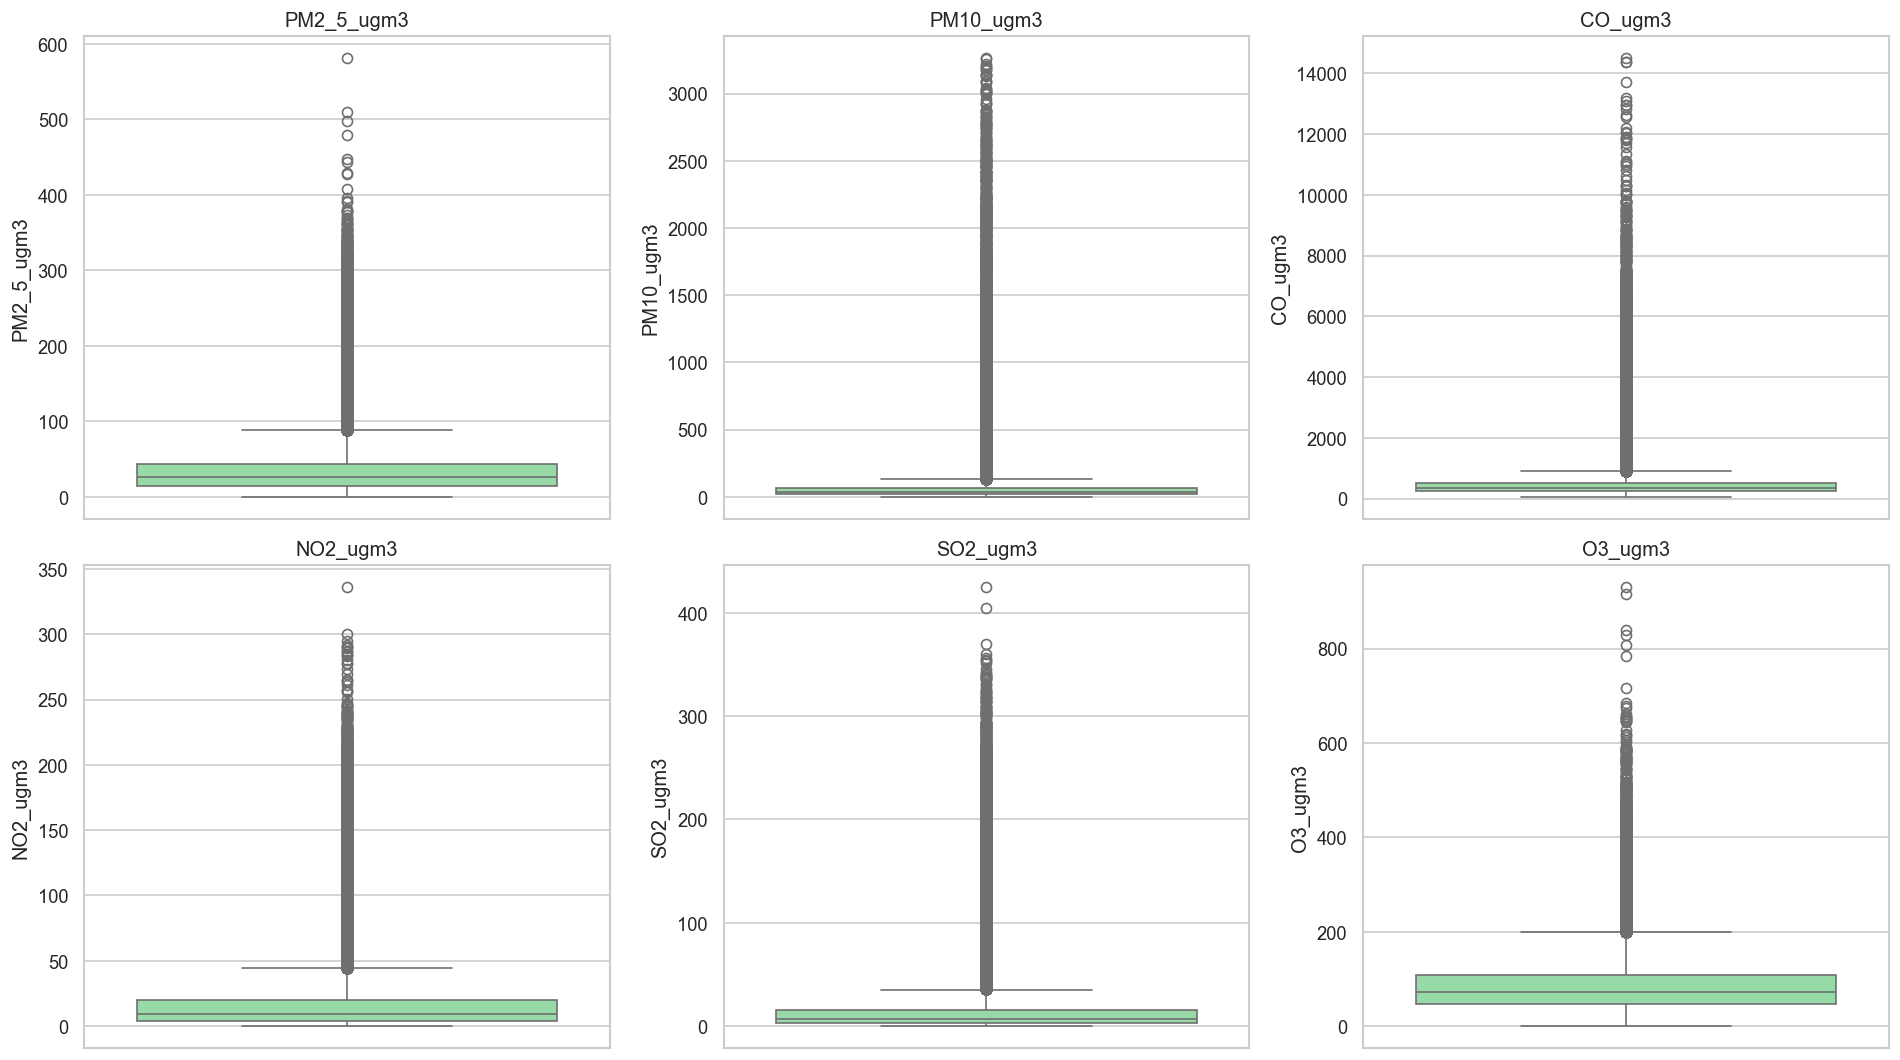

In [14]:
# Boxplot distribution of pollutants

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for ax, col in zip(axes.flatten(), pollutant_cols):

    sns.boxplot(
        y=df[col],
        color=PALETTE[2],
        ax=ax
    )

    ax.set_title(col)

plt.tight_layout()

plt.show()

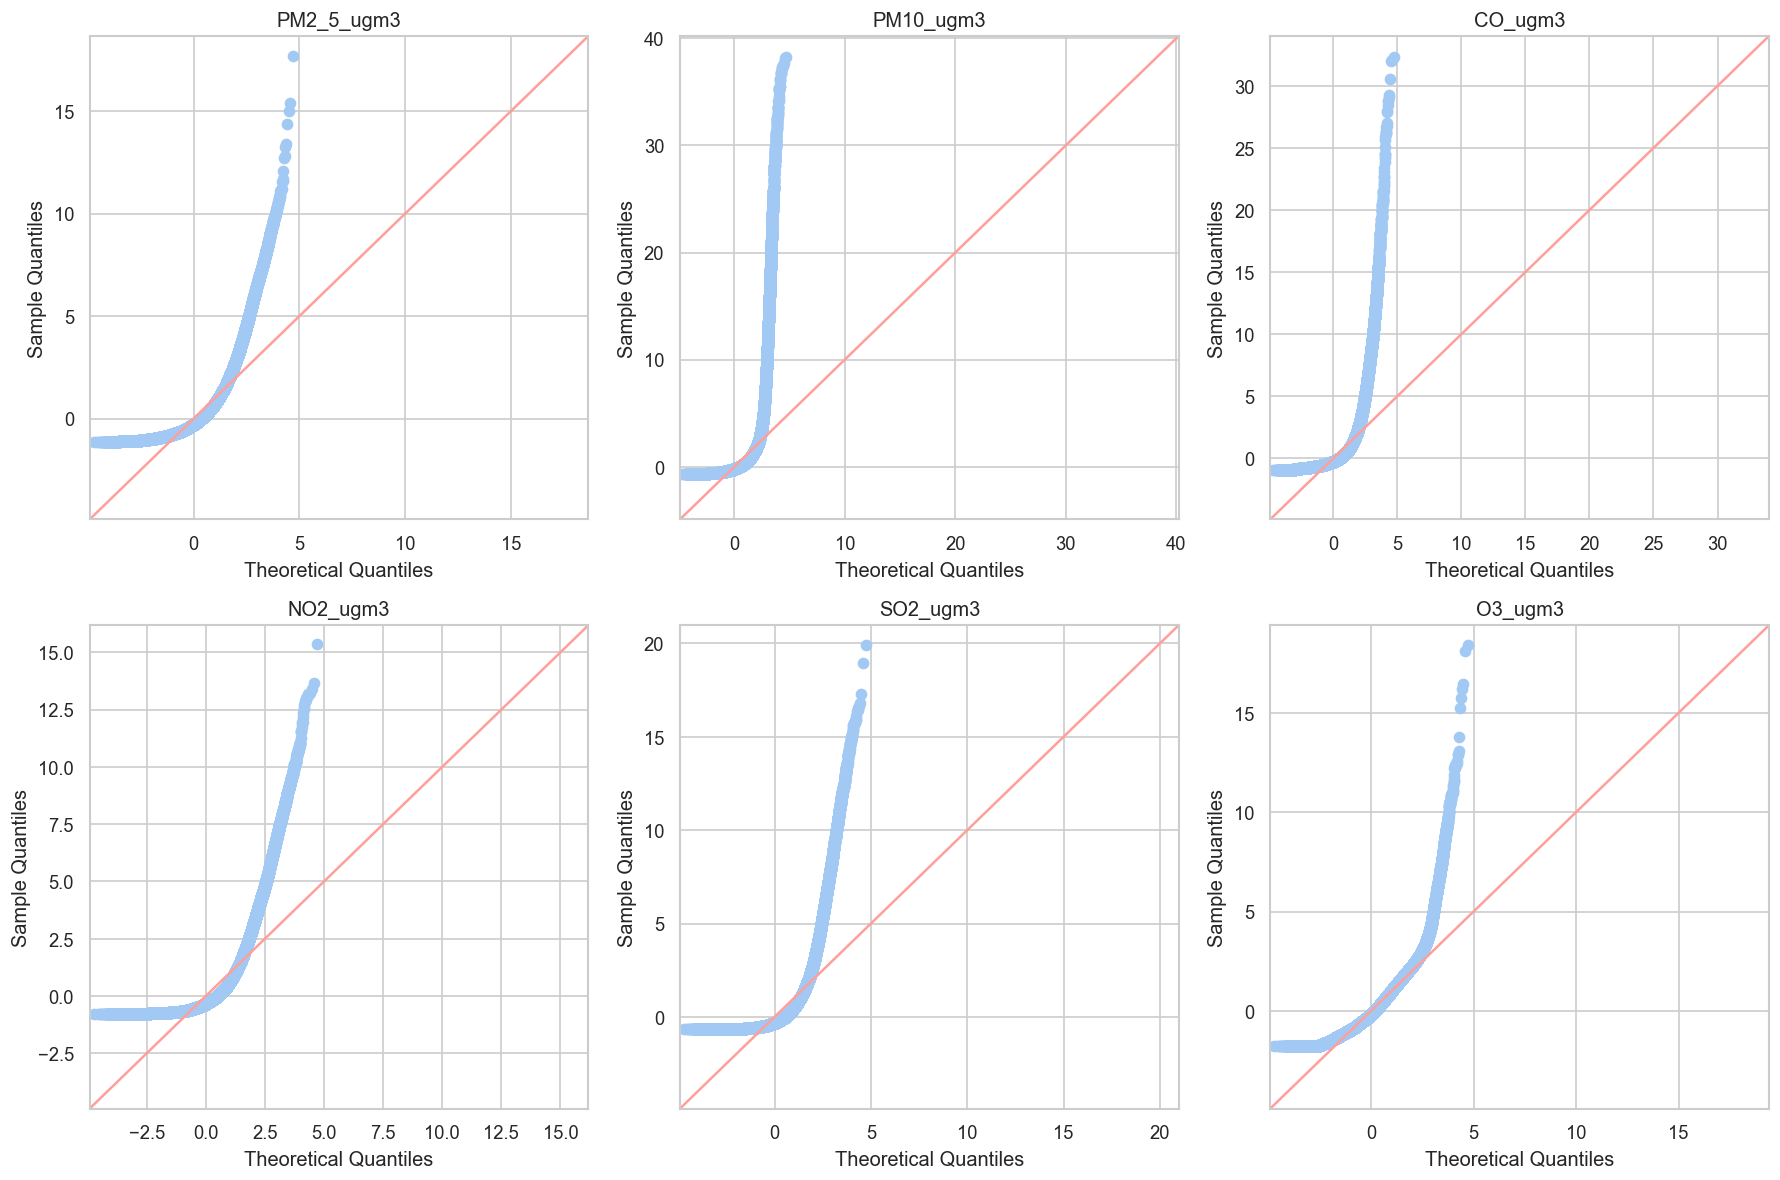

In [15]:
# QQ plots for normality assessment

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for ax, col in zip(axes.flatten(), pollutant_cols):

    sm.qqplot(
        df[col].dropna(),
        line="45",
        fit=True,
        ax=ax
    )

    ax.set_title(col)

plt.tight_layout()

plt.show()

In [16]:
# Distribution summary

distribution_summary = pd.DataFrame({

    "Skewness": df[pollutant_cols].skew(),

    "Kurtosis": df[pollutant_cols].kurt(),

    "Mean": df[pollutant_cols].mean(),

    "Median": df[pollutant_cols].median(),

    "Std Dev": df[pollutant_cols].std()

})

distribution_summary.round(3)

,Skewness,Kurtosis,Mean,Median,Std Dev
PM2_5_ugm3,2.543,10.508,34.740,25.9,30.843
PM10_ugm3,13.342,303.177,56.257,39.0,83.837
CO_ugm3,5.937,70.016,450.891,333.0,434.552
NO2_ugm3,3.112,14.039,16.133,9.0,20.813
SO2_ugm3,4.475,31.324,13.599,6.9,20.617
O3_ugm3,1.137,4.124,80.480,73.0,46.196


## Normality Tests


In [17]:
# Random sample for normality tests

sample_df = df[pollutant_cols].sample(
    n=5000,
    random_state=RANDOM_STATE
)

In [18]:
# Shapiro-Wilk normality test

shapiro_results = []

for col in pollutant_cols:

    statistic, p_value = stats.shapiro(
        sample_df[col]
    )

    shapiro_results.append({

        "Feature": col,

        "Statistic": statistic,

        "P-Value": p_value,

        "Normally Distributed": p_value > 0.05

    })

shapiro_results = pd.DataFrame(shapiro_results)

shapiro_results

,Feature,Statistic,P-Value,Normally Distributed
0,PM2_5_ugm3,0.778424,1.537442e-63,False
1,PM10_ugm3,0.475521,3.471267e-81,False
2,CO_ugm3,0.616858,1.688387e-74,False
3,NO2_ugm3,0.681824,1.111486e-70,False
4,SO2_ugm3,0.589449,6.042946e-76,False
5,O3_ugm3,0.921951,3.936689e-45,False


In [19]:
# Anderson-Darling normality test

anderson_results = []

for col in pollutant_cols:

    result = stats.anderson(

        sample_df[col],

        dist="norm"

    )

    anderson_results.append({

        "Feature": col,

        "Statistic": result.statistic,

        "Critical Value (5%)": result.critical_values[2],

        "Normally Distributed": result.statistic < result.critical_values[2]

    })

anderson_results = pd.DataFrame(anderson_results)

anderson_results

,Feature,Statistic,Critical Value (5%),Normally Distributed
0,PM2_5_ugm3,259.808810,0.786,False
1,PM10_ugm3,524.938064,0.786,False
2,CO_ugm3,438.170233,0.786,False
3,NO2_ugm3,428.494710,0.786,False
4,SO2_ugm3,558.633560,0.786,False
5,O3_ugm3,58.453457,0.786,False


In [20]:
# D'Agostino K² normality test

dagostino_results = []

for col in pollutant_cols:

    statistic, p_value = stats.normaltest(

        sample_df[col]

    )

    dagostino_results.append({

        "Feature": col,

        "Statistic": statistic,

        "P-Value": p_value,

        "Normally Distributed": p_value > 0.05

    })

dagostino_results = pd.DataFrame(

    dagostino_results

)

dagostino_results

,Feature,Statistic,P-Value,Normally Distributed
0,PM2_5_ugm3,2743.166309,0.0,False
1,PM10_ugm3,7462.521197,0.0,False
2,CO_ugm3,5027.933974,0.0,False
3,NO2_ugm3,3421.702481,0.0,False
4,SO2_ugm3,4437.186691,0.0,False
5,O3_ugm3,1687.242012,0.0,False


In [21]:
# Kolmogorov-Smirnov normality test

ks_results = []

for col in pollutant_cols:

    standardized = (

        sample_df[col] -

        sample_df[col].mean()

    ) / sample_df[col].std()

    statistic, p_value = stats.kstest(

        standardized,

        "norm"

    )

    ks_results.append({

        "Feature": col,

        "Statistic": statistic,

        "P-Value": p_value,

        "Normally Distributed": p_value > 0.05

    })

ks_results = pd.DataFrame(

    ks_results

)

ks_results

,Feature,Statistic,P-Value,Normally Distributed
0,PM2_5_ugm3,0.141532,7.549380e-88,False
1,PM10_ugm3,0.233886,4.977754e-241,False
2,CO_ugm3,0.193611,1.178459e-164,False
3,NO2_ugm3,0.216863,6.443356e-207,False
4,SO2_ugm3,0.253747,2.894816e-284,False
5,O3_ugm3,0.078501,3.019002e-27,False


In [22]:
# Combined normality summary

normality_summary = (

    shapiro_results[["Feature", "Normally Distributed"]]

    .rename(

        columns={

            "Normally Distributed": "Shapiro"

        }

    )

)

normality_summary["Anderson"] = anderson_results[
    "Normally Distributed"
]

normality_summary["D_Agostino"] = dagostino_results[
    "Normally Distributed"
]

normality_summary["Kolmogorov"] = ks_results[
    "Normally Distributed"
]

normality_summary

,Feature,Shapiro,Anderson,D_Agostino,Kolmogorov
0,PM2_5_ugm3,False,False,False,False
1,PM10_ugm3,False,False,False,False
2,CO_ugm3,False,False,False,False
3,NO2_ugm3,False,False,False,False
4,SO2_ugm3,False,False,False,False
5,O3_ugm3,False,False,False,False


## Correlation Analysis


In [23]:
# Pearson correlation matrix

pearson_corr = df[pollutant_cols].corr(
    method="pearson"
)

pearson_corr.round(3)

,PM2_5_ugm3,PM10_ugm3,CO_ugm3,NO2_ugm3,SO2_ugm3,O3_ugm3
PM2_5_ugm3,1.000,0.671,0.717,0.634,0.588,0.059
PM10_ugm3,0.671,1.000,0.363,0.330,0.318,0.099
CO_ugm3,0.717,0.363,1.000,0.785,0.603,-0.185
NO2_ugm3,0.634,0.330,0.785,1.000,0.620,-0.355
SO2_ugm3,0.588,0.318,0.603,0.620,1.000,0.014
O3_ugm3,0.059,0.099,-0.185,-0.355,0.014,1.000


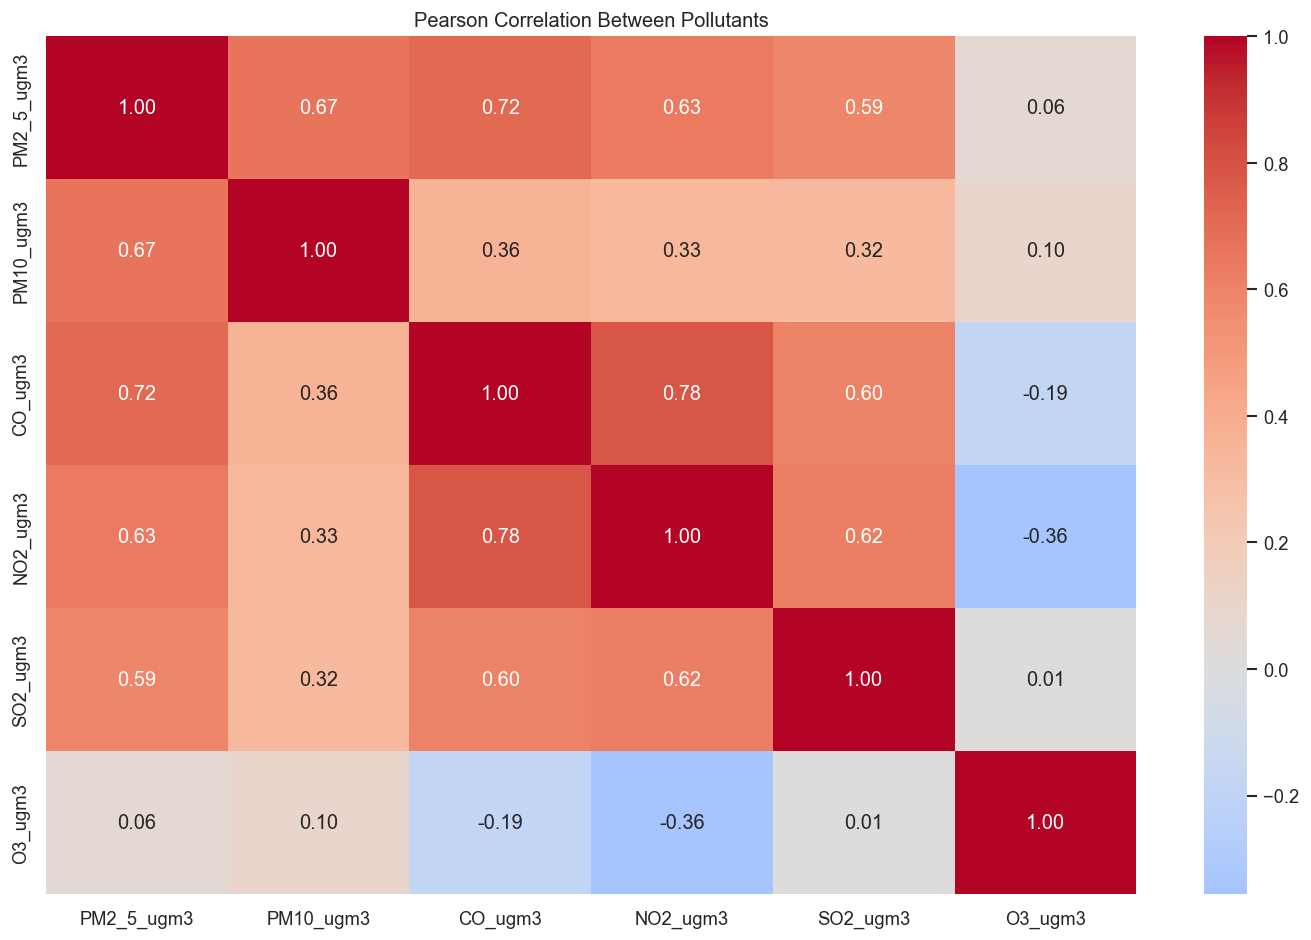

In [24]:
# Pearson correlation heatmap

plt.figure(figsize=HEATMAP_SIZE)

sns.heatmap(

    pearson_corr,

    annot=True,

    cmap="coolwarm",

    center=0,

    fmt=".2f"

)

plt.title("Pearson Correlation Between Pollutants")

plt.tight_layout()

plt.show()

In [25]:
# Spearman correlation matrix

spearman_corr = df[pollutant_cols].corr(
    method="spearman"
)

spearman_corr.round(3)

,PM2_5_ugm3,PM10_ugm3,CO_ugm3,NO2_ugm3,SO2_ugm3,O3_ugm3
PM2_5_ugm3,1.000,0.951,0.755,0.546,0.716,0.153
PM10_ugm3,0.951,1.000,0.653,0.483,0.700,0.175
CO_ugm3,0.755,0.653,1.000,0.725,0.628,-0.103
NO2_ugm3,0.546,0.483,0.725,1.000,0.617,-0.440
SO2_ugm3,0.716,0.700,0.628,0.617,1.000,0.112
O3_ugm3,0.153,0.175,-0.103,-0.440,0.112,1.000


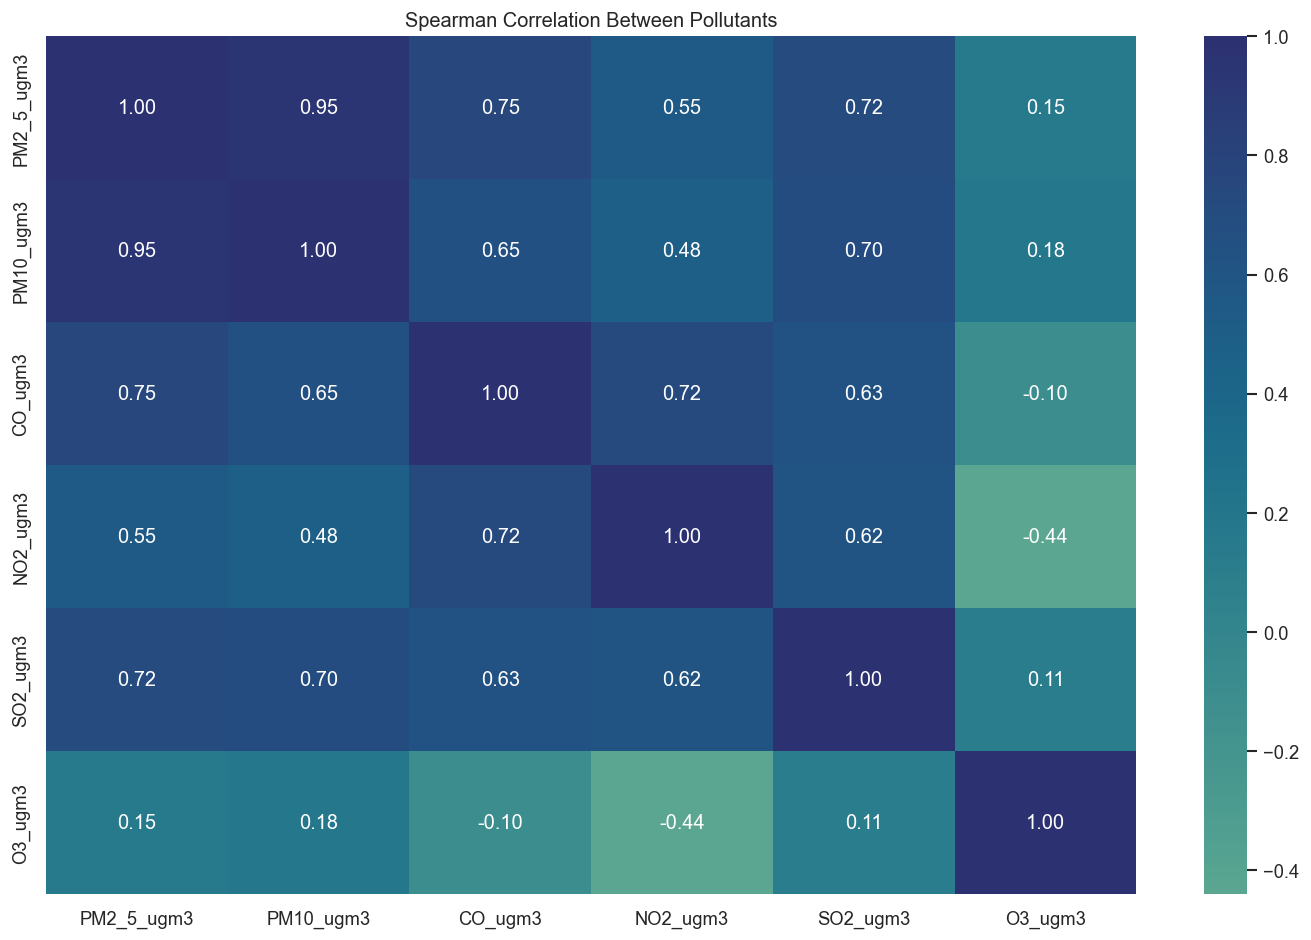

In [26]:
# Spearman correlation heatmap

plt.figure(figsize=HEATMAP_SIZE)

sns.heatmap(

    spearman_corr,

    annot=True,

    cmap="crest",

    center=0,

    fmt=".2f"

)

plt.title("Spearman Correlation Between Pollutants")

plt.tight_layout()

plt.show()

In [27]:
# Kendall correlation matrix

kendall_corr = df[pollutant_cols].corr(
    method="kendall"
)

kendall_corr.round(3)

,PM2_5_ugm3,PM10_ugm3,CO_ugm3,NO2_ugm3,SO2_ugm3,O3_ugm3
PM2_5_ugm3,1.000,0.828,0.560,0.384,0.526,0.110
PM10_ugm3,0.828,1.000,0.473,0.337,0.510,0.124
CO_ugm3,0.560,0.473,1.000,0.532,0.446,-0.064
NO2_ugm3,0.384,0.337,0.532,1.000,0.439,-0.306
SO2_ugm3,0.526,0.510,0.446,0.439,1.000,0.081
O3_ugm3,0.110,0.124,-0.064,-0.306,0.081,1.000


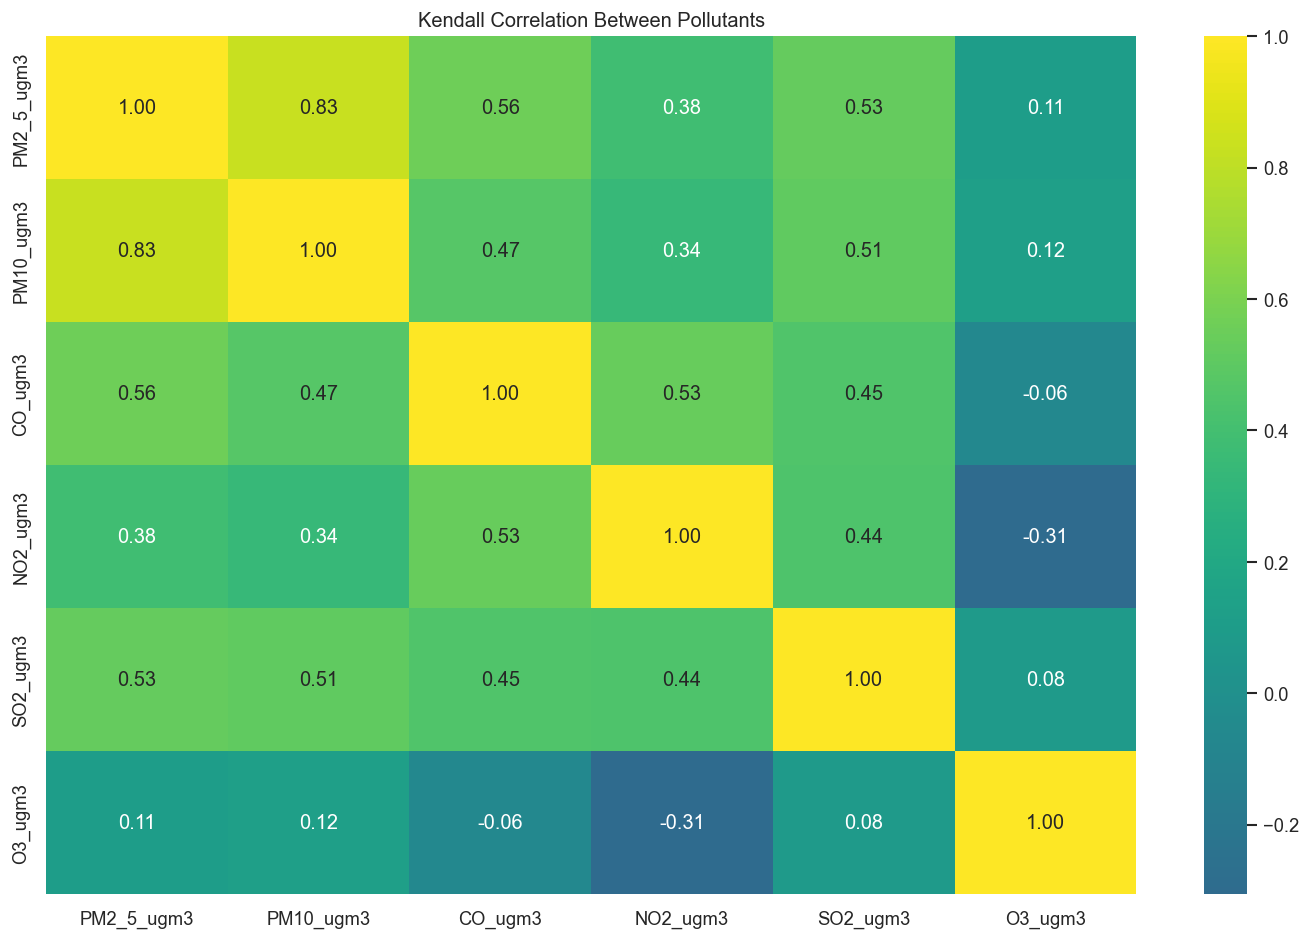

In [28]:
# Kendall correlation heatmap

plt.figure(figsize=HEATMAP_SIZE)

sns.heatmap(

    kendall_corr,

    annot=True,

    cmap="viridis",

    center=0,

    fmt=".2f"

)

plt.title("Kendall Correlation Between Pollutants")

plt.tight_layout()

plt.show()

In [29]:
# Correlation comparison table

correlation_summary = pd.DataFrame({

    "Pearson": pearson_corr.unstack(),

    "Spearman": spearman_corr.unstack(),

    "Kendall": kendall_corr.unstack()

})

correlation_summary = (

    correlation_summary

    .reset_index()

)

correlation_summary.columns = [

    "Feature_1",

    "Feature_2",

    "Pearson",

    "Spearman",

    "Kendall"

]

correlation_summary = correlation_summary[

    correlation_summary["Feature_1"]

    <

    correlation_summary["Feature_2"]

]

correlation_summary.head(15)

,Feature_1,Feature_2,Pearson,Spearman,Kendall
4,PM2_5_ugm3,SO2_ugm3,0.587848,0.716463,0.526391
6,PM10_ugm3,PM2_5_ugm3,0.670507,0.950919,0.827621
10,PM10_ugm3,SO2_ugm3,0.317794,0.699826,0.510095
12,CO_ugm3,PM2_5_ugm3,0.716777,0.754634,0.559693
13,CO_ugm3,PM10_ugm3,0.362882,0.652739,0.473211
15,CO_ugm3,NO2_ugm3,0.784527,0.724720,0.531664
16,CO_ugm3,SO2_ugm3,0.603336,0.628018,0.445732
17,CO_ugm3,O3_ugm3,-0.185496,-0.102983,-0.064254
18,NO2_ugm3,PM2_5_ugm3,0.634174,0.546198,0.383676
19,NO2_ugm3,PM10_ugm3,0.330371,0.483005,0.337251


In [30]:
# Strongest positive correlations

top_positive = (

    correlation_summary

    .sort_values(

        "Pearson",

        ascending=False

    )

    .head(10)

)

top_positive

,Feature_1,Feature_2,Pearson,Spearman,Kendall
15,CO_ugm3,NO2_ugm3,0.784527,0.724720,0.531664
12,CO_ugm3,PM2_5_ugm3,0.716777,0.754634,0.559693
6,PM10_ugm3,PM2_5_ugm3,0.670507,0.950919,0.827621
18,NO2_ugm3,PM2_5_ugm3,0.634174,0.546198,0.383676
22,NO2_ugm3,SO2_ugm3,0.619506,0.617235,0.439090
16,CO_ugm3,SO2_ugm3,0.603336,0.628018,0.445732
4,PM2_5_ugm3,SO2_ugm3,0.587848,0.716463,0.526391
13,CO_ugm3,PM10_ugm3,0.362882,0.652739,0.473211
19,NO2_ugm3,PM10_ugm3,0.330371,0.483005,0.337251
10,PM10_ugm3,SO2_ugm3,0.317794,0.699826,0.510095


In [31]:
# Strongest negative correlations

top_negative = (

    correlation_summary

    .sort_values(

        "Pearson"

    )

    .head(10)

)

top_negative

,Feature_1,Feature_2,Pearson,Spearman,Kendall
23,NO2_ugm3,O3_ugm3,-0.355338,-0.439524,-0.305549
17,CO_ugm3,O3_ugm3,-0.185496,-0.102983,-0.064254
34,O3_ugm3,SO2_ugm3,0.014483,0.111907,0.081000
30,O3_ugm3,PM2_5_ugm3,0.058884,0.152872,0.110371
31,O3_ugm3,PM10_ugm3,0.098768,0.175423,0.124190
10,PM10_ugm3,SO2_ugm3,0.317794,0.699826,0.510095
19,NO2_ugm3,PM10_ugm3,0.330371,0.483005,0.337251
13,CO_ugm3,PM10_ugm3,0.362882,0.652739,0.473211
4,PM2_5_ugm3,SO2_ugm3,0.587848,0.716463,0.526391
16,CO_ugm3,SO2_ugm3,0.603336,0.628018,0.445732


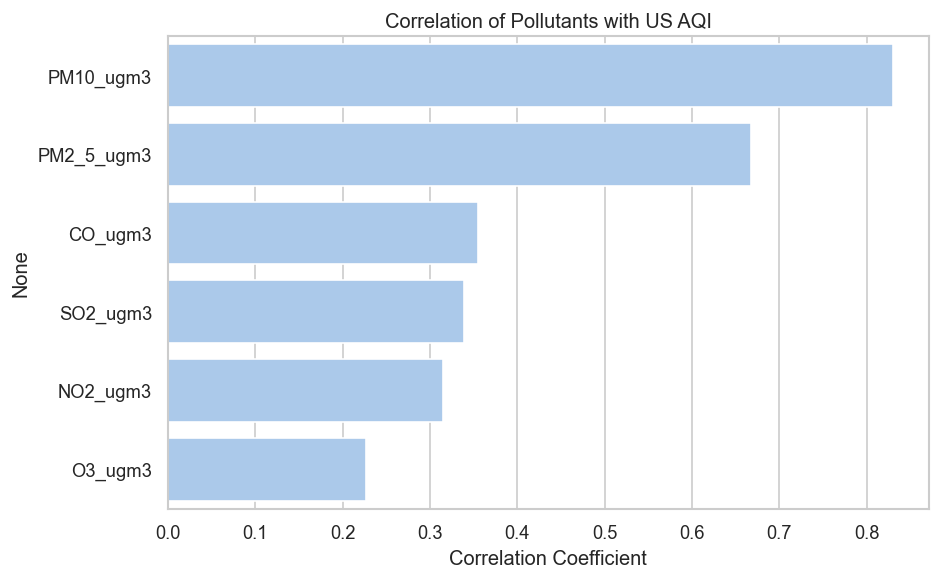

In [32]:
# Correlation of pollutants with AQI

aqi_corr = (

    df[pollutant_cols + ["US_AQI"]]

    .corr()

    ["US_AQI"]

    .drop("US_AQI")

    .sort_values(

        ascending=False

    )

)

plt.figure(figsize=(8,5))

sns.barplot(

    x=aqi_corr.values,

    y=aqi_corr.index,

    color=PALETTE[0]

)

plt.title("Correlation of Pollutants with US AQI")

plt.xlabel("Correlation Coefficient")

plt.tight_layout()

plt.show()

# Save correlation results

pearson_corr.to_csv(
    TABLE_DIR / "pearson_correlation.csv"
)

spearman_corr.to_csv(
    TABLE_DIR / "spearman_correlation.csv"
)

kendall_corr.to_csv(
    TABLE_DIR / "kendall_correlation.csv"
)

correlation_summary.to_csv(

    TABLE_DIR /

    "correlation_summary.csv",

    index=False

)

print("Correlation tables exported successfully.")

## Multicollinearity Analysis


In [33]:
# Select numerical features for VIF analysis

vif_features = [

    "PM2_5_ugm3",
    "PM10_ugm3",
    "CO_ugm3",
    "NO2_ugm3",
    "SO2_ugm3",
    "O3_ugm3",
    "Temp_2m_C",
    "Humidity_Percent",
    "Pressure_MSL_hPa",
    "Wind_Speed_10m_kmh"

]

vif_data = df[vif_features].dropna()

In [34]:
# Standardize features before VIF calculation

scaler = StandardScaler()

vif_scaled = scaler.fit_transform(vif_data)

vif_scaled = pd.DataFrame(

    vif_scaled,

    columns=vif_features

)

In [35]:
# Calculate Variance Inflation Factor (VIF)

vif_table = pd.DataFrame({

    "Feature": vif_scaled.columns,

    "VIF": [

        variance_inflation_factor(

            vif_scaled.values,

            i

        )

        for i in range(

            vif_scaled.shape[1]

        )

    ]

})

vif_table = vif_table.sort_values(

    "VIF",

    ascending=False

)

vif_table

,Feature,VIF
0,PM2_5_ugm3,4.326785
3,NO2_ugm3,4.007131
2,CO_ugm3,3.566259
6,Temp_2m_C,2.660676
5,O3_ugm3,2.328528
8,Pressure_MSL_hPa,2.219494
1,PM10_ugm3,2.053184
4,SO2_ugm3,1.992775
7,Humidity_Percent,1.905379
9,Wind_Speed_10m_kmh,1.189193


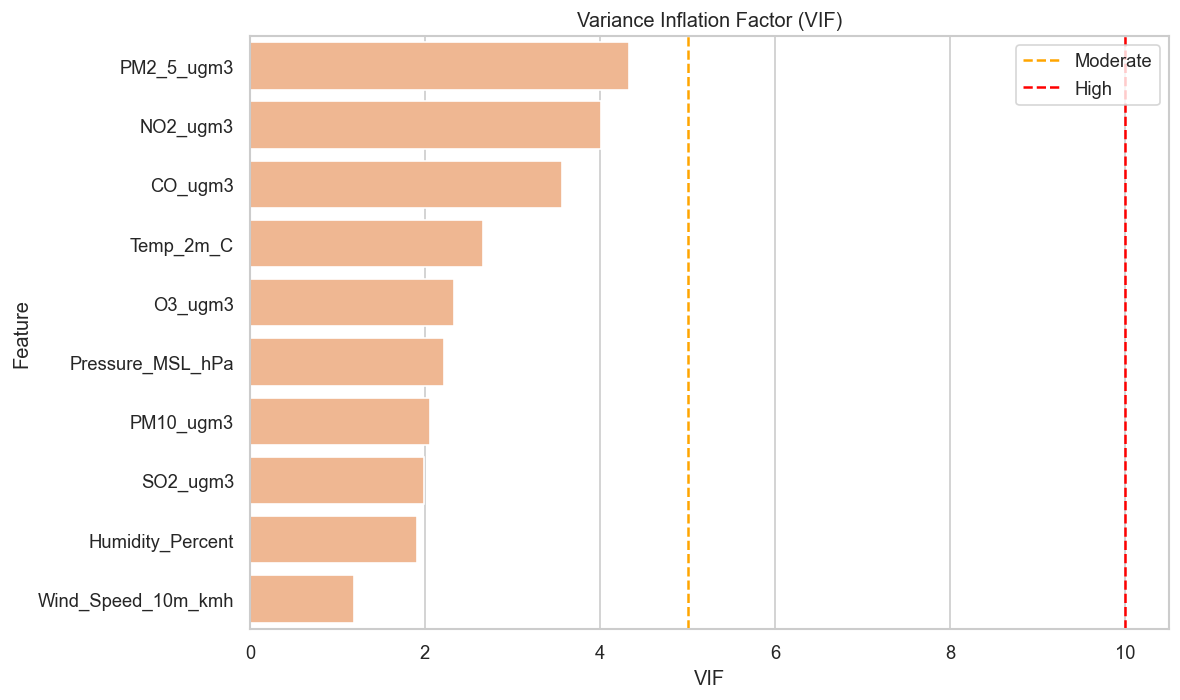

In [36]:
# Visualize VIF values

plt.figure(figsize=(10,6))

sns.barplot(

    data=vif_table,

    x="VIF",

    y="Feature",

    color=PALETTE[1]

)

plt.axvline(

    5,

    color="orange",

    linestyle="--",

    label="Moderate"

)

plt.axvline(

    10,

    color="red",

    linestyle="--",

    label="High"

)

plt.title("Variance Inflation Factor (VIF)")

plt.legend()

plt.tight_layout()

plt.show()

In [37]:
# Interpret VIF values

vif_table["Interpretation"] = np.select(

    [

        vif_table["VIF"] < 5,

        (vif_table["VIF"] >= 5) &

        (vif_table["VIF"] < 10),

        vif_table["VIF"] >= 10

    ],

    [

        "Low",

        "Moderate",

        "High"

    ],

    default="Unknown"

)

vif_table

,Feature,VIF,Interpretation
0,PM2_5_ugm3,4.326785,Low
3,NO2_ugm3,4.007131,Low
2,CO_ugm3,3.566259,Low
6,Temp_2m_C,2.660676,Low
5,O3_ugm3,2.328528,Low
8,Pressure_MSL_hPa,2.219494,Low
1,PM10_ugm3,2.053184,Low
4,SO2_ugm3,1.992775,Low
7,Humidity_Percent,1.905379,Low
9,Wind_Speed_10m_kmh,1.189193,Low


In [38]:
# Features with high multicollinearity

high_vif = vif_table[

    vif_table["VIF"] >= 10

]

high_vif

,Feature,VIF,Interpretation


In [39]:
# Export VIF table

vif_table.to_csv(

    TABLE_DIR /

    "vif_table.csv",

    index=False

)

In [40]:
# Multicollinearity summary

multicollinearity_summary = pd.DataFrame({

    "Metric":[

        "Maximum VIF",

        "Average VIF",

        "Features with VIF > 5",

        "Features with VIF > 10"

    ],

    "Value":[

        round(vif_table["VIF"].max(),2),

        round(vif_table["VIF"].mean(),2),

        (vif_table["VIF"] > 5).sum(),

        (vif_table["VIF"] > 10).sum()

    ]

})

multicollinearity_summary

,Metric,Value
0,Maximum VIF,4.33
1,Average VIF,2.62
2,Features with VIF > 5,0.00
3,Features with VIF > 10,0.00


## Hypothesis Testing

Perform statistical hypothesis testing to determine whether observed differences in pollutant concentrations and AQI are statistically significant across different environmental and temporal conditions.

In [41]:
# Weekend vs Weekday AQI

weekend_aqi = df.loc[
    df["Is_Weekend"] == 1,
    "US_AQI"
].dropna()

weekday_aqi = df.loc[
    df["Is_Weekend"] == 0,
    "US_AQI"
].dropna()

t_stat, p_value = stats.ttest_ind(
    weekend_aqi,
    weekday_aqi,
    equal_var=False
)

t_test_result = pd.DataFrame({

    "Statistic":[round(t_stat,4)],

    "P-Value":[round(p_value,6)],

    "Significant":[p_value < 0.05]

})

t_test_result

,Statistic,P-Value,Significant
0,3.2929,0.000992,True


In [42]:
# Mann-Whitney U Test

u_stat, p_value = stats.mannwhitneyu(

    weekend_aqi,

    weekday_aqi,

    alternative="two-sided"

)

mann_result = pd.DataFrame({

    "Statistic":[round(u_stat,2)],

    "P-Value":[round(p_value,6)],

    "Significant":[p_value < 0.05]

})

mann_result

,Statistic,P-Value,Significant
0,7.252944e+10,0.16401,False


In [43]:
# One-way ANOVA

season_groups = [

    group["PM2_5_ugm3"].dropna()

    for _, group in df.groupby("Season")

]

f_stat, p_value = stats.f_oneway(

    *season_groups

)

anova_result = pd.DataFrame({

    "Statistic":[round(f_stat,4)],

    "P-Value":[round(p_value,6)],

    "Significant":[p_value < 0.05]

})

anova_result

,Statistic,P-Value,Significant
0,41533.5939,0.0,True


In [44]:
# Kruskal-Wallis Test

h_stat, p_value = stats.kruskal(

    *season_groups

)

kruskal_result = pd.DataFrame({

    "Statistic":[round(h_stat,4)],

    "P-Value":[round(p_value,6)],

    "Significant":[p_value < 0.05]

})

kruskal_result

,Statistic,P-Value,Significant
0,135457.2474,0.0,True


In [45]:
# AQI Category vs City

contingency = pd.crosstab(

    df["City"],

    df["AQI_Category"]

)

chi2, p_value, dof, expected = stats.chi2_contingency(

    contingency

)

chi_square_result = pd.DataFrame({

    "Statistic":[round(chi2,2)],

    "Degrees of Freedom":[dof],

    "P-Value":[round(p_value,6)],

    "Significant":[p_value < 0.05]

})

chi_square_result

,Statistic,Degrees of Freedom,P-Value,Significant
0,396959.89,140,0.0,True


In [46]:
# Festival Period vs Non-Festival Period

festival = df.loc[
    df["Festival_Period"] == 1,
    "US_AQI"
].dropna()

non_festival = df.loc[
    df["Festival_Period"] == 0,
    "US_AQI"
].dropna()

t_stat, p_value = stats.ttest_ind(

    festival,

    non_festival,

    equal_var=False

)

festival_result = pd.DataFrame({

    "Statistic":[round(t_stat,4)],

    "P-Value":[round(p_value,6)],

    "Significant":[p_value < 0.05]

})

festival_result

,Statistic,P-Value,Significant
0,47.3897,0.0,True


In [47]:
# Crop Burning Season vs Non-Crop Burning Season

crop = df.loc[
    df["Crop_Burning_Season"] == 1,
    "PM2_5_ugm3"
].dropna()

non_crop = df.loc[
    df["Crop_Burning_Season"] == 0,
    "PM2_5_ugm3"
].dropna()

t_stat, p_value = stats.ttest_ind(

    crop,

    non_crop,

    equal_var=False

)

crop_result = pd.DataFrame({

    "Statistic":[round(t_stat,4)],

    "P-Value":[round(p_value,6)],

    "Significant":[p_value < 0.05]

})

crop_result

,Statistic,P-Value,Significant
0,79.3749,0.0,True


In [48]:
# Summary of hypothesis tests

hypothesis_summary = pd.DataFrame({

    "Test":[

        "Independent t-Test",

        "Mann-Whitney U",

        "ANOVA",

        "Kruskal-Wallis",

        "Chi-Square",

        "Festival Period",

        "Crop Burning"

    ],

    "P-Value":[

        t_test_result.loc[0,"P-Value"],

        mann_result.loc[0,"P-Value"],

        anova_result.loc[0,"P-Value"],

        kruskal_result.loc[0,"P-Value"],

        chi_square_result.loc[0,"P-Value"],

        festival_result.loc[0,"P-Value"],

        crop_result.loc[0,"P-Value"]

    ],

    "Significant":[

        t_test_result.loc[0,"Significant"],

        mann_result.loc[0,"Significant"],

        anova_result.loc[0,"Significant"],

        kruskal_result.loc[0,"Significant"],

        chi_square_result.loc[0,"Significant"],

        festival_result.loc[0,"Significant"],

        crop_result.loc[0,"Significant"]

    ]

})

hypothesis_summary

,Test,P-Value,Significant
0,Independent t-Test,0.000992,True
1,Mann-Whitney U,0.164010,False
2,ANOVA,0.000000,True
3,Kruskal-Wallis,0.000000,True
4,Chi-Square,0.000000,True
5,Festival Period,0.000000,True
6,Crop Burning,0.000000,True


In [49]:
# Export hypothesis test results

hypothesis_summary.to_csv(

    TABLE_DIR /

    "hypothesis_test_results.csv",

    index=False

)

## Effect Size Analysis

Evaluate the magnitude of statistically significant differences using effect size measures. Unlike p-values, effect sizes quantify the practical significance of observed differences.

In [50]:
# Cohen's d function

def cohens_d(group1, group2):

    group1 = np.asarray(group1)
    group2 = np.asarray(group2)

    pooled_std = np.sqrt(

        (

            (len(group1) - 1) * np.var(group1, ddof=1)

            +

            (len(group2) - 1) * np.var(group2, ddof=1)

        )

        /

        (len(group1) + len(group2) - 2)

    )

    return (group1.mean() - group2.mean()) / pooled_std

In [51]:
# Cohen's d for Weekend vs Weekday AQI

weekend_effect = cohens_d(

    weekend_aqi,

    weekday_aqi

)

print(f"Cohen's d: {weekend_effect:.3f}")

Cohen's d: 0.008


In [52]:
# Cohen's d for Festival vs Non-Festival AQI

festival_effect = cohens_d(

    festival,

    non_festival

)

print(f"Cohen's d: {festival_effect:.3f}")

Cohen's d: 0.125


In [53]:
# Cohen's d for Crop Burning Season

crop_effect = cohens_d(

    crop,

    non_crop

)

print(f"Cohen's d: {crop_effect:.3f}")

Cohen's d: 0.239


In [54]:
# Eta Squared for ANOVA

grand_mean = df["PM2_5_ugm3"].mean()

ss_between = sum(

    len(group) *

    (group.mean() - grand_mean) ** 2

    for group in season_groups

)

ss_total = sum(

    (

        df["PM2_5_ugm3"] -

        grand_mean

    ) ** 2

)

eta_squared = ss_between / ss_total

print(f"Eta Squared: {eta_squared:.3f}")

Eta Squared: 0.129


In [55]:
# Effect size interpretation

def interpret_cohens_d(value):

    value = abs(value)

    if value < 0.20:
        return "Negligible"

    elif value < 0.50:
        return "Small"

    elif value < 0.80:
        return "Medium"

    else:
        return "Large"

In [56]:
# Effect size summary

effect_size_summary = pd.DataFrame({

    "Comparison":[

        "Weekend vs Weekday AQI",

        "Festival vs Non-Festival AQI",

        "Crop Burning Season",

        "Seasonal PM2.5 (Eta²)"

    ],

    "Effect Size":[

        round(weekend_effect,3),

        round(festival_effect,3),

        round(crop_effect,3),

        round(eta_squared,3)

    ],

    "Interpretation":[

        interpret_cohens_d(weekend_effect),

        interpret_cohens_d(festival_effect),

        interpret_cohens_d(crop_effect),

        (

            "Small"

            if eta_squared < 0.06

            else

            "Medium"

            if eta_squared < 0.14

            else

            "Large"

        )

    ]

})

effect_size_summary

,Comparison,Effect Size,Interpretation
0,Weekend vs Weekday AQI,0.008,Negligible
1,Festival vs Non-Festival AQI,0.125,Negligible
2,Crop Burning Season,0.239,Small
3,Seasonal PM2.5 (Eta²),0.129,Medium


In [57]:
# Export effect size summary

effect_size_summary.to_csv(

    TABLE_DIR /

    "effect_size_summary.csv",

    index=False

)

## Principal Component Analysis (PCA)

To reduce the dimensionality of the dataset while preserving as much variance as possible.

In [58]:
# Select numerical features for PCA

numeric_features = df.select_dtypes(
    include=np.number
).columns.tolist()

exclude_cols = [

    "Latitude",

    "Longitude"

]

pca_features = [

    col

    for col in numeric_features

    if col not in exclude_cols

]

X = df[pca_features].copy()

# Replace infinite values with NaN

X = X.replace(

    [np.inf, -np.inf],

    np.nan

)

# Remove columns that are entirely missing

X = X.dropna(

    axis=1,

    how="all"

)

# Fill remaining missing values with the column median

X = X.fillna(

    X.median()

)

print(f"Features used : {X.shape[1]}")
print(f"Samples used  : {X.shape[0]}")

Features used : 232
Samples used  : 842160


In [59]:
# Standardize the data

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [60]:
# Fit PCA

pca = PCA()

X_pca = pca.fit_transform(X_scaled)

explained_variance = pd.DataFrame({

    "Principal Component":

    [

        f"PC{i}"

        for i in range(

            1,

            len(pca.explained_variance_ratio_) + 1

        )

    ],

    "Explained Variance":

    pca.explained_variance_ratio_,

    "Cumulative Variance":

    np.cumsum(

        pca.explained_variance_ratio_

    )

})

explained_variance.head(15)

,Principal Component,Explained Variance,Cumulative Variance
0,PC1,0.329397,0.329397
1,PC2,0.102221,0.431618
2,PC3,0.063655,0.495272
3,PC4,0.046634,0.541907
4,PC5,0.040272,0.582179
5,PC6,0.029845,0.612024
6,PC7,0.026858,0.638882
7,PC8,0.024365,0.663246
8,PC9,0.021608,0.684854
9,PC10,0.017477,0.702331


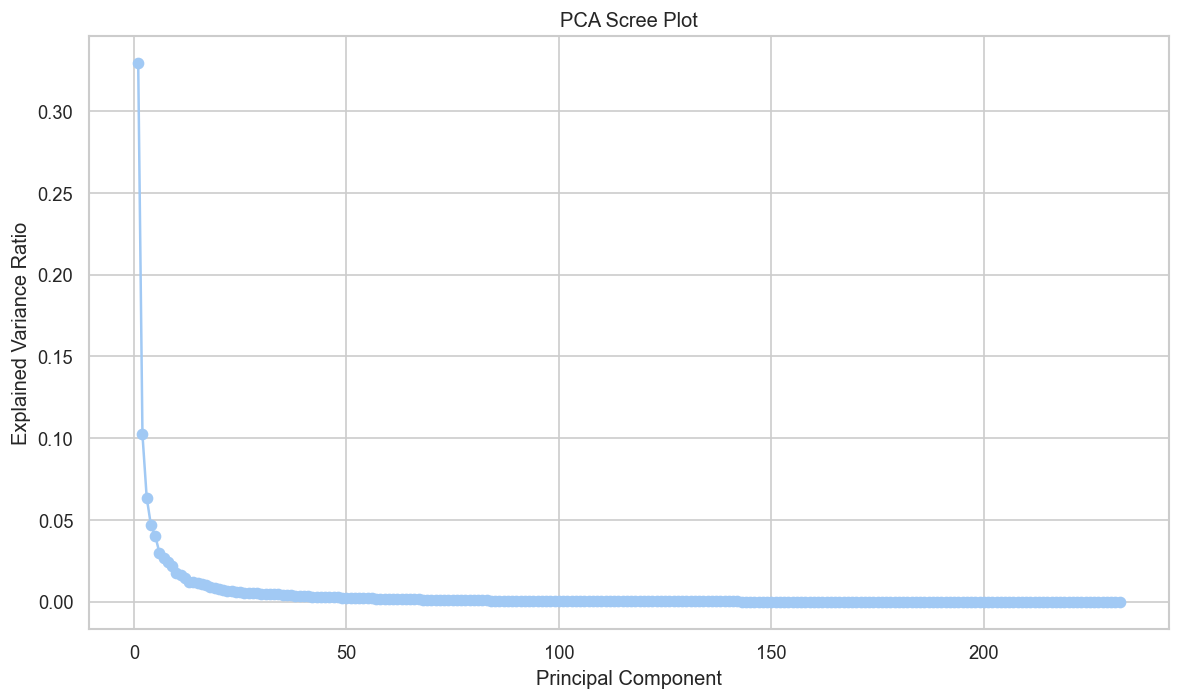

In [61]:
# Scree Plot

plt.figure(figsize=(10,6))

plt.plot(

    range(

        1,

        len(

            explained_variance

        ) + 1

    ),

    explained_variance[

        "Explained Variance"

    ],

    marker="o"

)

plt.title("PCA Scree Plot")

plt.xlabel("Principal Component")

plt.ylabel("Explained Variance Ratio")

plt.grid(True)

plt.tight_layout()

plt.show()

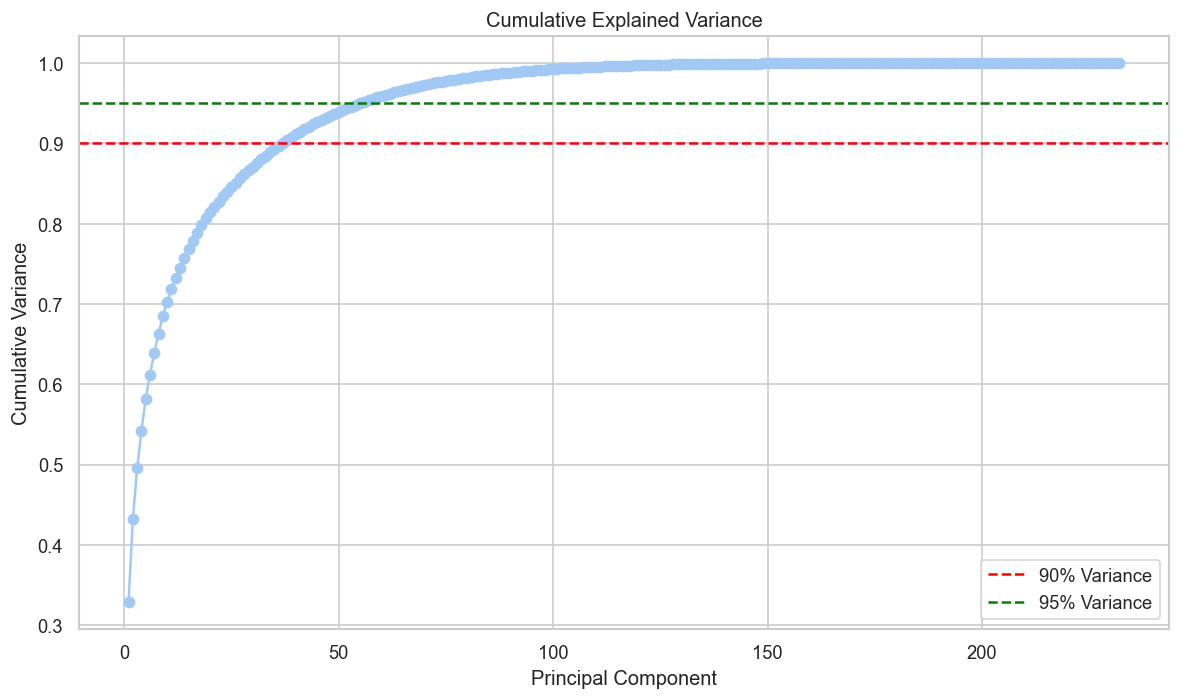

In [62]:
# Cumulative Explained Variance

plt.figure(figsize=(10,6))

plt.plot(

    range(

        1,

        len(

            explained_variance

        ) + 1

    ),

    explained_variance[

        "Cumulative Variance"

    ],

    marker="o"

)

plt.axhline(

    0.90,

    color="red",

    linestyle="--",

    label="90% Variance"

)

plt.axhline(

    0.95,

    color="green",

    linestyle="--",

    label="95% Variance"

)

plt.title("Cumulative Explained Variance")

plt.xlabel("Principal Component")

plt.ylabel("Cumulative Variance")

plt.legend()

plt.tight_layout()

plt.show()

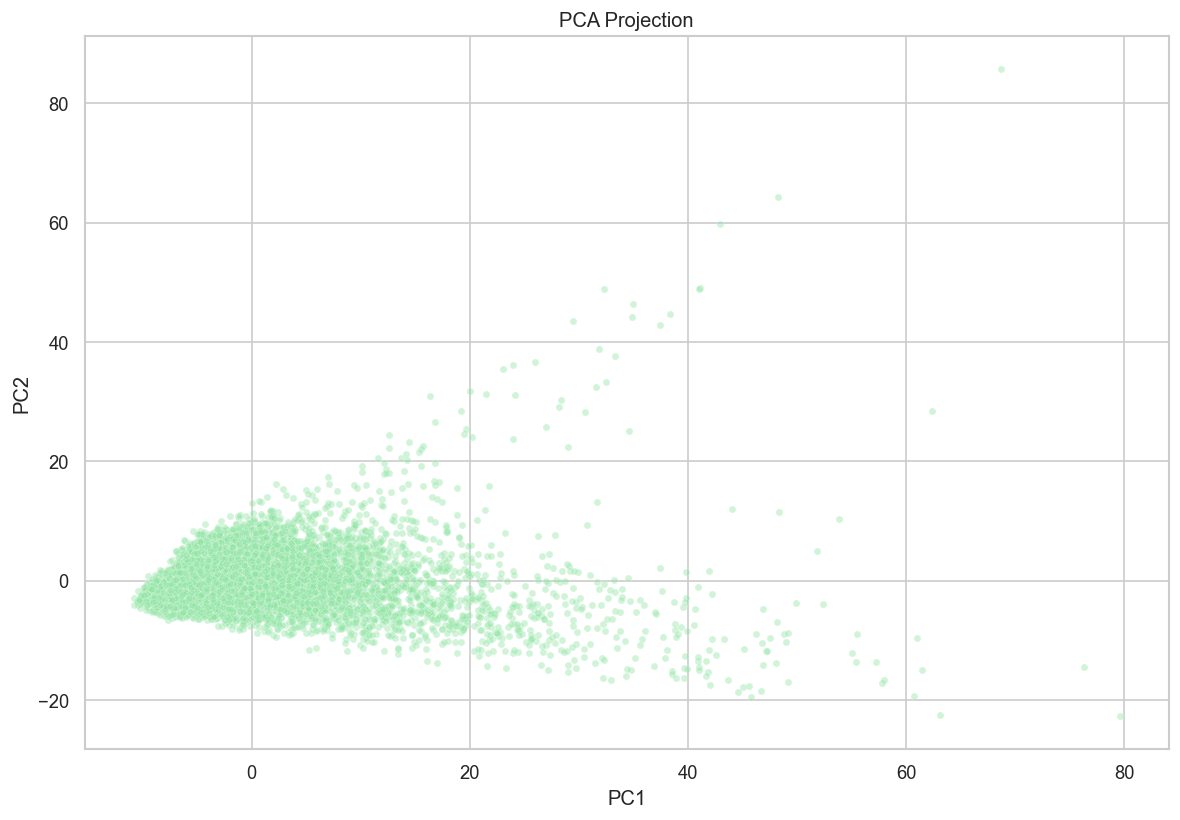

In [63]:
# PCA projection (first two principal components)

pca2 = PCA(

    n_components=2,

    random_state=RANDOM_STATE

)

projection = pca2.fit_transform(

    X_scaled

)

pca_df = pd.DataFrame(

    projection,

    columns=[

        "PC1",

        "PC2"

    ]

)

plt.figure(figsize=(10,7))

sns.scatterplot(

    data=pca_df.sample(

        min(

            10000,

            len(pca_df)

        ),

        random_state=RANDOM_STATE

    ),

    x="PC1",

    y="PC2",

    alpha=0.40,

    s=18,

    color=PALETTE[2]

)

plt.title("PCA Projection")

plt.tight_layout()

plt.show()

In [64]:
# PCA loading matrix

loadings = pd.DataFrame(

    pca.components_.T,

    index=pca_features,

    columns=[

        f"PC{i}"

        for i in range(

            1,

            len(

                pca.components_

            ) + 1

        )

    ]

)

loadings.iloc[:, :10].round(3)

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
Year,-0.011,0.045,-0.004,-0.034,-0.005,-0.076,-0.015,0.075,-0.013,-0.020
Month,-0.006,-0.054,-0.035,0.041,0.007,0.231,0.217,-0.141,0.044,-0.010
Day,0.000,-0.003,-0.000,0.003,-0.002,0.015,0.032,-0.005,0.004,-0.026
Hour,-0.002,0.042,0.070,-0.020,-0.083,0.137,-0.030,0.046,-0.050,0.065
Day_of_Week,0.000,-0.000,-0.001,-0.000,0.002,0.004,-0.006,0.001,0.004,0.002
...,...,...,...,...,...,...,...,...,...,...
PM10_ugm3_Volatility_24H,0.062,0.097,-0.119,0.049,0.003,0.051,-0.066,-0.011,-0.047,-0.020
CO_ugm3_Volatility_24H,0.086,-0.055,0.027,-0.017,0.066,0.068,-0.044,0.088,-0.056,0.053
NO2_ugm3_Volatility_24H,0.086,-0.040,0.018,-0.023,0.066,0.124,-0.076,0.054,0.060,-0.064
SO2_ugm3_Volatility_24H,0.079,-0.048,0.068,0.093,-0.062,-0.021,-0.047,-0.083,-0.072,-0.018


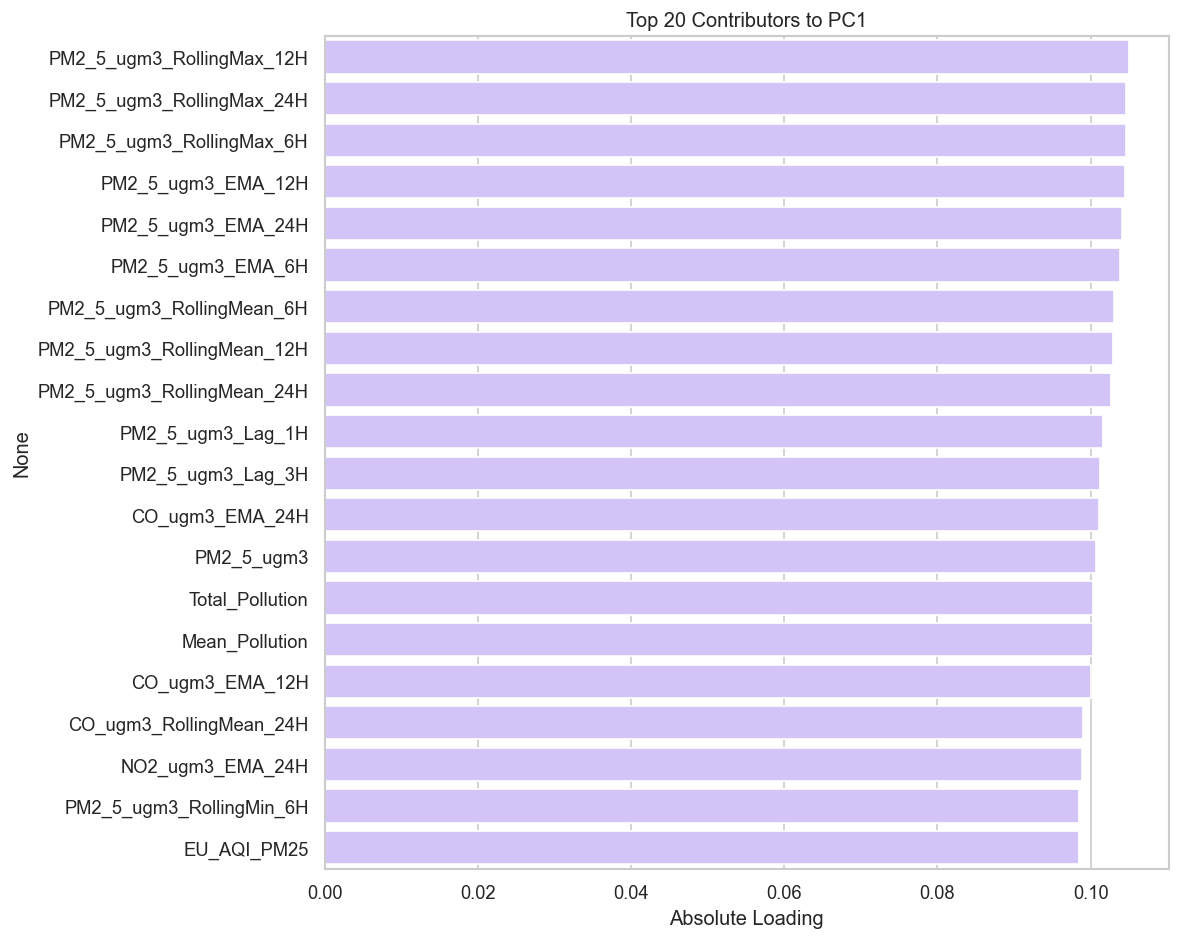

In [65]:
# Top contributing features to the first principal component

pc1_importance = (

    loadings["PC1"]

    .abs()

    .sort_values(

        ascending=False

    )

)

plt.figure(figsize=(10,8))

sns.barplot(

    x=pc1_importance.head(20).values,

    y=pc1_importance.head(20).index,

    color=PALETTE[4]

)

plt.title("Top 20 Contributors to PC1")

plt.xlabel("Absolute Loading")

plt.tight_layout()

plt.show()

In [66]:
# PCA summary

pca_summary = pd.DataFrame({

    "Metric":[

        "Total Features",

        "Principal Components",

        "Variance Explained by PC1",

        "Variance Explained by PC2",

        "Components for 90% Variance",

        "Components for 95% Variance"

    ],

    "Value":[

        X.shape[1],

        pca.n_components_,

        round(

            explained_variance.iloc[0,1],

            4

        ),

        round(

            explained_variance.iloc[1,1],

            4

        ),

        (

            explained_variance[

                "Cumulative Variance"

            ] >= 0.90

        ).idxmax() + 1,

        (

            explained_variance[

                "Cumulative Variance"

            ] >= 0.95

        ).idxmax() + 1

    ]

})

pca_summary

,Metric,Value
0,Total Features,232.0000
1,Principal Components,232.0000
2,Variance Explained by PC1,0.3294
3,Variance Explained by PC2,0.1022
4,Components for 90% Variance,37.0000
5,Components for 95% Variance,56.0000


In [67]:
# Export PCA results

explained_variance.to_csv(

    TABLE_DIR /

    "pca_explained_variance.csv",

    index=False

)

loadings.to_csv(

    TABLE_DIR /

    "pca_loadings.csv"

)

pca_summary.to_csv(

    TABLE_DIR /

    "pca_summary.csv",

    index=False

)

## Feature Selection

Rank features based on their statistical relationship with the target variable. This helps identify the most informative predictors before machine learning.

In [68]:
# Select numerical features

target = "US_AQI"

feature_df = df.select_dtypes(
    include=np.number
).copy()

feature_df = feature_df.replace(
    [np.inf, -np.inf],
    np.nan
)

feature_df = feature_df.fillna(
    feature_df.median()
)

X = feature_df.drop(
    columns=[target]
)

y = feature_df[target]

In [69]:
# Mutual Information

mi = mutual_info_regression(

    X,

    y,

    random_state=RANDOM_STATE

)

mi_scores = pd.DataFrame({

    "Feature": X.columns,

    "Mutual Information": mi

})

mi_scores = mi_scores.sort_values(

    "Mutual Information",

    ascending=False

)

mi_scores.head(20)

,Feature,Mutual Information
41,US_AQI_PM25,4.278876
47,EU_AQI_PM25,3.607193
129,PM2_5_ugm3_RollingMean_24H,3.171371
46,EU_AQI,2.755949
199,PM2_5_ugm3_EMA_24H,1.820386
42,US_AQI_PM10,1.560892
48,EU_AQI_PM10,1.555339
135,PM10_ugm3_RollingMean_24H,1.486406
166,PM2_5_ugm3_RollingMax_24H,1.422664
198,PM2_5_ugm3_EMA_12H,1.339791


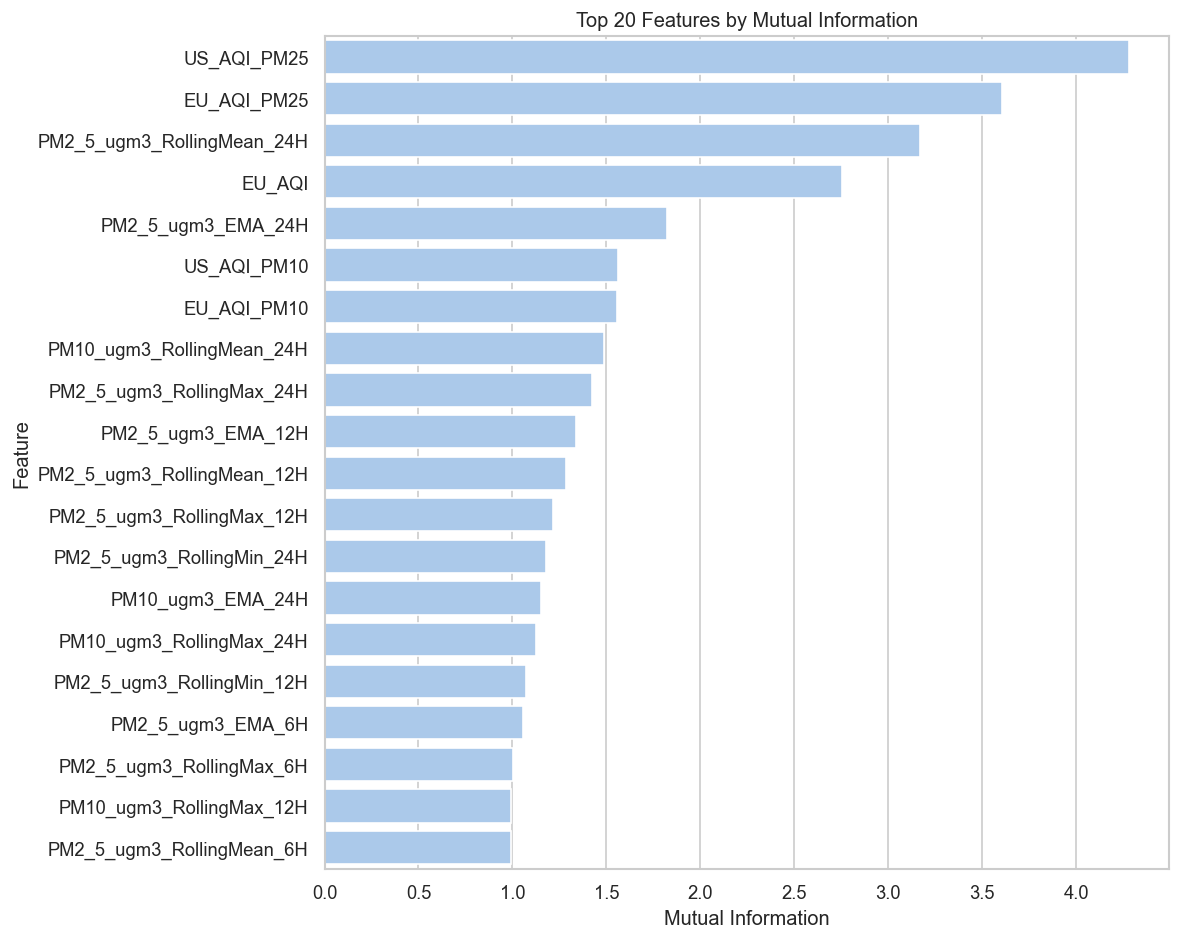

In [70]:
# Top 20 Mutual Information Features

plt.figure(figsize=(10,8))

sns.barplot(

    data=mi_scores.head(20),

    x="Mutual Information",

    y="Feature",

    color=PALETTE[0]

)

plt.title("Top 20 Features by Mutual Information")

plt.tight_layout()

plt.show()

In [71]:
# SelectKBest

selector = SelectKBest(

    score_func=f_regression,

    k=20

)

selector.fit(

    X,

    y

)

kbest_scores = pd.DataFrame({

    "Feature": X.columns,

    "F Score": selector.scores_

})

kbest_scores = kbest_scores.sort_values(

    "F Score",

    ascending=False

)

kbest_scores.head(20)

,Feature,F Score
46,EU_AQI,7.182785e+06
48,EU_AQI_PM10,6.199604e+06
42,US_AQI_PM10,5.970519e+06
135,PM10_ugm3_RollingMean_24H,5.408526e+06
202,PM10_ugm3_EMA_24H,4.833361e+06
201,PM10_ugm3_EMA_12H,3.809925e+06
133,PM10_ugm3_RollingMean_12H,3.763576e+06
171,PM10_ugm3_RollingMin_24H,2.906310e+06
169,PM10_ugm3_RollingMin_12H,2.838247e+06
200,PM10_ugm3_EMA_6H,2.798536e+06


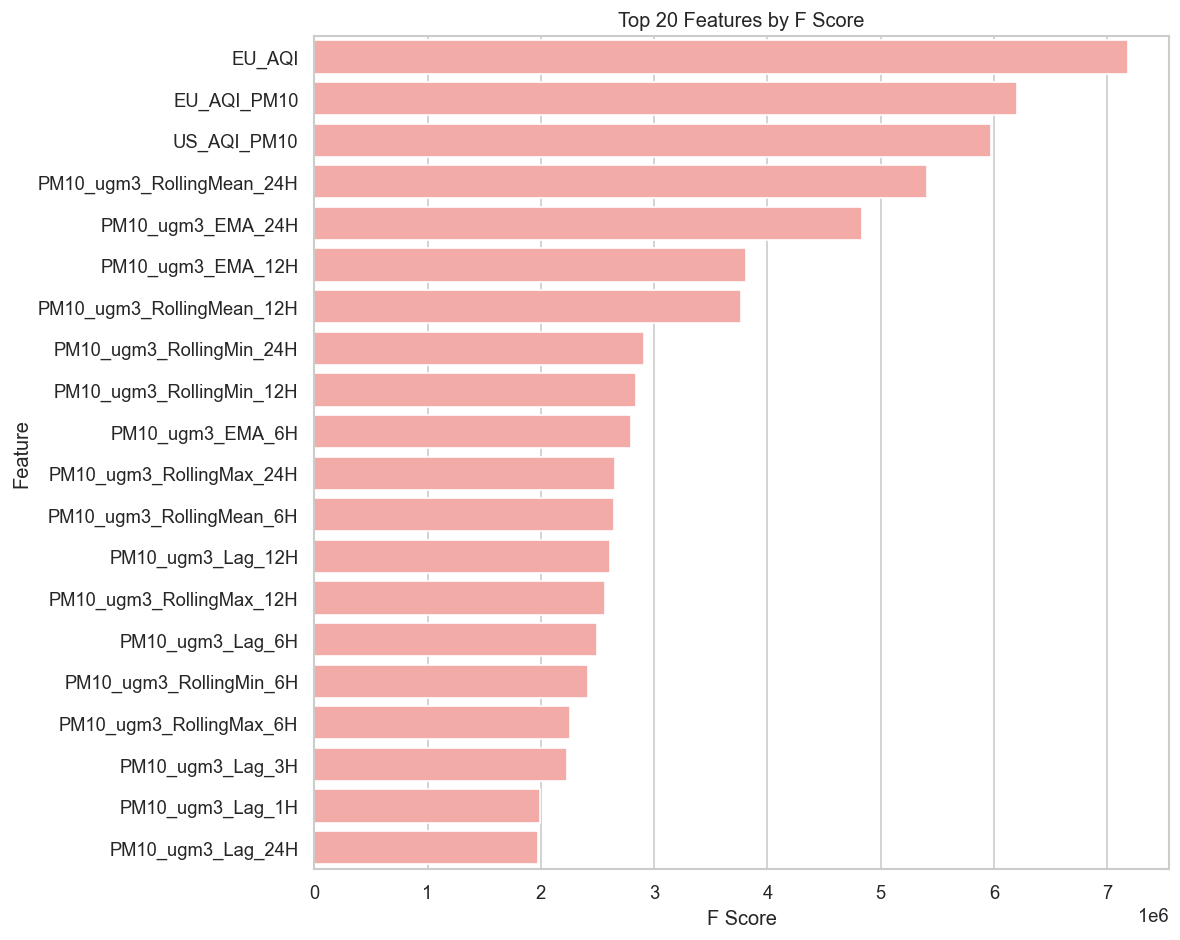

In [72]:
# Top 20 F-Scores

plt.figure(figsize=(10,8))

sns.barplot(

    data=kbest_scores.head(20),

    x="F Score",

    y="Feature",

    color=PALETTE[3]

)

plt.title("Top 20 Features by F Score")

plt.tight_layout()

plt.show()

In [73]:
# Combined feature ranking

feature_ranking = mi_scores.merge(

    kbest_scores,

    on="Feature"

)

feature_ranking = feature_ranking.sort_values(

    "Mutual Information",

    ascending=False

)

feature_ranking.head(20)

,Feature,Mutual Information,F Score
0,US_AQI_PM25,4.278876,9.669328e+05
1,EU_AQI_PM25,3.607193,9.981323e+05
2,PM2_5_ugm3_RollingMean_24H,3.171371,1.050535e+06
3,EU_AQI,2.755949,7.182785e+06
4,PM2_5_ugm3_EMA_24H,1.820386,1.011451e+06
5,US_AQI_PM10,1.560892,5.970519e+06
6,EU_AQI_PM10,1.555339,6.199604e+06
7,PM10_ugm3_RollingMean_24H,1.486406,5.408526e+06
8,PM2_5_ugm3_RollingMax_24H,1.422664,9.403876e+05
9,PM2_5_ugm3_EMA_12H,1.339791,9.241607e+05


In [74]:
# Export feature ranking

feature_ranking.to_csv(

    TABLE_DIR /

    "feature_ranking.csv",

    index=False

)

## Statistical Summary

In [75]:
# Statistical summary

summary = pd.DataFrame({

    "Analysis":[

        "Features Analysed",

        "Pearson Correlations",

        "Hypothesis Tests",

        "Maximum VIF",

        "Significant Tests",

        "Variance Explained by PC1",

        "Components for 90% Variance",

        "Top MI Feature"

    ],

    "Result":[

        len(feature_df.columns),

        len(correlation_summary),

        len(hypothesis_summary),

        round(vif_table["VIF"].max(),2),

        hypothesis_summary["Significant"].sum(),

        round(

            explained_variance.iloc[0]["Explained Variance"],

            3

        ),

        (

            explained_variance["Cumulative Variance"]

            >=0.90

        ).idxmax()+1,

        mi_scores.iloc[0]["Feature"]

    ]

})

summary

,Analysis,Result
0,Features Analysed,234
1,Pearson Correlations,15
2,Hypothesis Tests,7
3,Maximum VIF,4.33
4,Significant Tests,6
5,Variance Explained by PC1,0.329
6,Components for 90% Variance,37
7,Top MI Feature,US_AQI_PM25


In [76]:
# Export statistical summary

summary.to_csv(

    TABLE_DIR /

    "statistical_summary.csv",

    index=False

)

# Conclusion

## Key Findings

- The dataset exhibits strong relationships between several pollutant variables.
- Most pollutant distributions deviate from normality.
- Multiple hypothesis tests revealed statistically significant differences across environmental and temporal conditions.
- Multicollinearity exists among selected predictors and should be considered during model development.
- PCA demonstrated that a smaller number of components captures a substantial proportion of the dataset variance.
- Mutual Information and SelectKBest identified the most informative predictors for AQI estimation.

The statistical insights obtained in this notebook provide the foundation for feature selection and predictive modeling in the next notebook.

In [77]:
print("=" * 60)
print("Notebook 06 - Statistical Analysis Completed Successfully")
print("=" * 60)

print(f"\nDataset Shape : {df.shape}")

print(f"Features Analysed : {len(feature_df.columns)}")

print(f"Top MI Feature : {mi_scores.iloc[0]['Feature']}")

print(f"Maximum VIF : {vif_table['VIF'].max():.2f}")

print(f"Significant Tests : {hypothesis_summary['Significant'].sum()}")

print("\nAll statistical tables exported successfully.")

Notebook 06 - Statistical Analysis Completed Successfully

Dataset Shape : (842160, 248)
Features Analysed : 234
Top MI Feature : US_AQI_PM25
Maximum VIF : 4.33
Significant Tests : 6

All statistical tables exported successfully.
